# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# cargar archivos

plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")


In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print("Cantidad de valores nulos:\n", users.isna().sum())
print("\nProporción de valores nulos:\n", users.isna().mean())

Cantidad de valores nulos:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:\n", usage.isna().sum())
print("\nProporción de valores nulos:\n", usage.isna().mean())

Cantidad de valores nulos:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  users: Tiene un alto porcentaje de nulos ~90%, pero indican que el usuario está activo y no ha cancelado el servicio; la acción es ignorar, mantener como nulo o rellenar con un indicador como 'activo'.

usage: No presenta valores nulos en sus variables clave de consumo; la acción es no realizar ninguna modificación.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [17]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`Son identificadores únicos por lo que los promedios y métricas estadísticos no aplican comercialmente; sirven para unir las tablas
- Las columnas numéricas de uso: Muestran valores promedio y desviaciones estándar que permiten identificar el comportamiento de consumo y detectar sesgos hacia la derecha (uso extremo o atípico).

In [18]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].value_counts(dropna=False))
    print()

--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` Muestra la distribución geográfica de los clientes entre México y Colombia, permitiendo detectar concentraciones regionales.
- La columna `plan` Muestra la proporción de usuarios suscritos a los planes Básico vs. Premium para evaluar la cuota de mercado interna.
  

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

- La columna `type` Identifica el volumen relativo de eventos según el tipo de servicio utilizado (llamadas vs. mensajes), permitiendo entender la preferencia del canal de comunicación.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  Columnas encontradas: Se detectan valores sentinels o fuera de rango (como -1, 999 o cadenas genéricas como 'UNKNOWN') en las métricas numéricas de usage (duración/longitud) o en users (edades o registros atípicos).  
- ¿Qué acción tomarías?
Reemplazar los valores sentinels por NaN mediante np.nan para evitar que distorsionen los cálculos estadísticos (medias y desviaciones), e imputarlos o filtrarlos según la regla de negocio del proyecto.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [21]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, la mayoría de los usuarios se registraron entre 2022 y 2024 de forma uniforme, pero aparecen 40 registros etiquetados en el año 2026

In [22]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, observo 39,950 registros concentrados en el año 2024 y 50 valores faltantes (NaN)

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
En usage "Date" no aparecen años imposibles como tal, pero existen 50 registros nulos (NaN) generados por formatos inválidos al aplicar errors='coerce'. En users "rage_date" sí aparecen 40 fechas del año 2026
- ¿Qué harías con ellas?
  
Para las fechas faltantes en usage, investigar si corresponden a errores de lectura o eliminarlas si representan una fracción insignificante del total (<0.2%). Para el año 2026 en users, reemplazar esos valores por NaT para evitar sesgar el cálculo de antigüedad.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [25]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [27]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

Los nulos en duration ocurren únicamente cuando el evento es un mensaje tipo message, y los nulos en length se presentan solo cuando el evento es una llamada tipo call.
Como la ausencia de datos depende directamente del tipo de servicio utilizado, se confirma la condición de MAR. Por lo tanto, se dejan como nulos sin imputar, ya que una llamada no posee longitud de mensaje ni un mensaje posee duración en minutos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg({"is_text": "sum", "is_call": "sum", "duration": "sum"})
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(
    columns={
        "is_text": "cant_mensajes",
        "is_call": "cant_llamadas",
        "duration": "cant_minutos_llamada",
    }
)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
cols_numericas = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile[cols_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

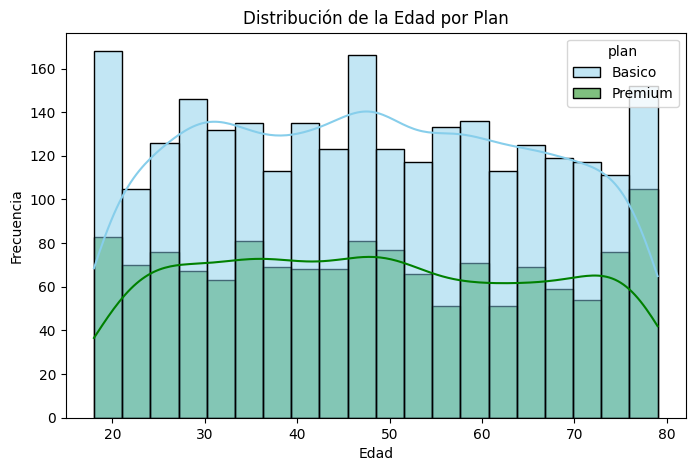

In [33]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 5))
sns.histplot(
    data=users,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20,
)
plt.title("Distribución de la Edad por Plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
-Distribución: Simétrica (relativamente uniforme a lo largo de los rangos de edad).

Patrón de negocio: No se observa un sesgo marcado por edad según el plan; los usuarios de todas las edades contrataron tanto el plan Básico como el Premium de manera homogénea.

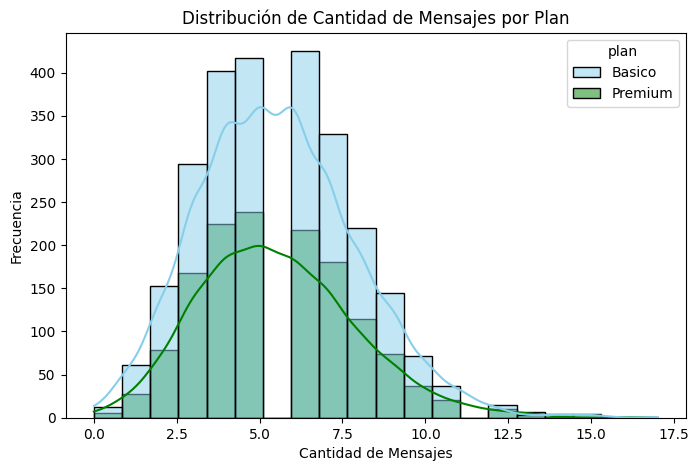

In [35]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20,
)
plt.title("Distribución de Cantidad de Mensajes por Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
Distribución: Sesgada a la derecha (asimetría positiva).

Patrón de negocio: La mayoría de los usuarios envía un número bajo de mensajes (concentración cerca de cero). Sin embargo, los usuarios del plan Premium muestran una cola más larga hacia la derecha, alcanzando volúmenes de envío significativamente mayores que los del plan Básico.

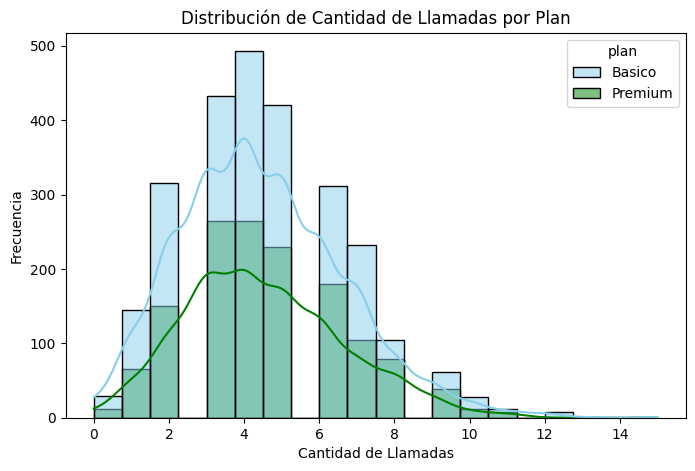

In [37]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20,
)
plt.title("Distribución de Cantidad de Llamadas por Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Distribución: Sesgada a la derecha (asimetría positiva).

Patrón de negocio: Los usuarios del plan Básico tienden a hacer una cantidad moderada/baja de llamadas. Dentro del plan Premium, existe una mayor proporción de usuarios en los rangos de alta frecuencia de llamadas.

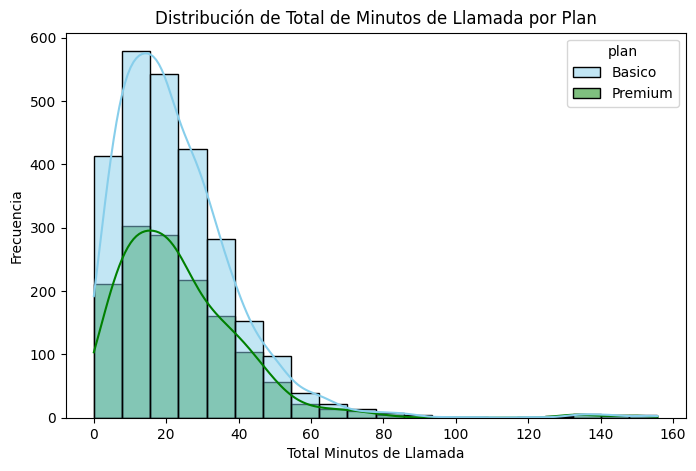

In [38]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 5))
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20,
)
plt.title("Distribución de Total de Minutos de Llamada por Plan")
plt.xlabel("Total Minutos de Llamada")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Distribución: Sesgada a la derecha (asimetría positiva).

Patrón de negocio: El consumo en minutos del plan Básico se agrupa fuertemente cerca de su límite contratado, mientras que los usuarios Premium concentran consumos elevados y dispersos, aprovechando la bolsa ampliada de minutos incluidos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

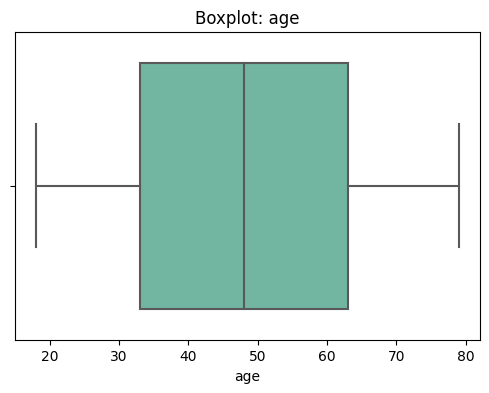

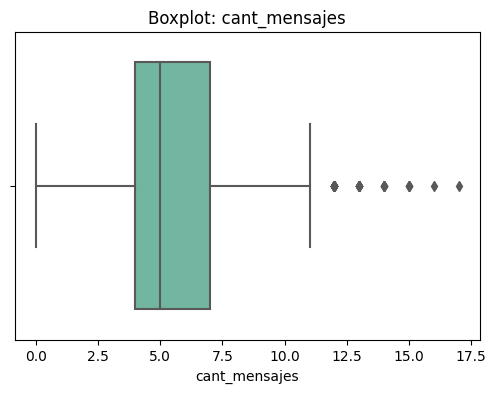

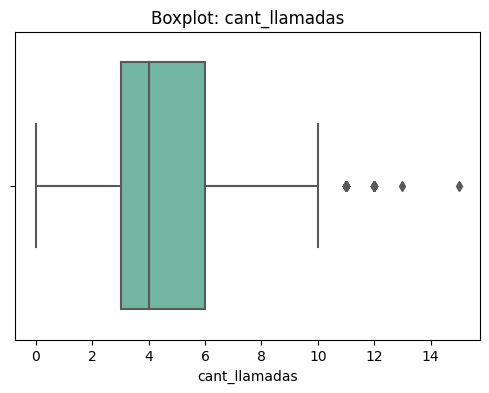

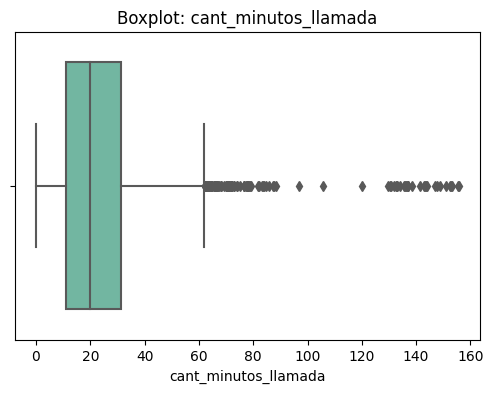

In [39]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, x=col, palette='Set2')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers; los datos de edad están bien acotados tras la limpieza del sentinel.
- cant_mensajes: Presenta outliers hacia el lado superior (valores atípicos de alto consumo).
- cant_llamadas: Presenta outliers superiores en la cola derecha.
- cant_minutos_llamada: Presenta outliers superiores correspondientes a usuarios intensivos.

In [40]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    print(f"--- {col} ---")
    print(f"Q1: {q1} | Q3: {q3} | IQR: {iqr}")
    print(f"Límite superior IQR: {limite_superior:.2f}")
    print(f"Máximo real en datos: {user_profile[col].max()}\n")



--- cant_mensajes ---
Q1: 4.0 | Q3: 7.0 | IQR: 3.0
Límite superior IQR: 11.50
Máximo real en datos: 17.0

--- cant_llamadas ---
Q1: 3.0 | Q3: 6.0 | IQR: 3.0
Límite superior IQR: 10.50
Máximo real en datos: 15.0

--- cant_minutos_llamada ---
Q1: 11.12 | Q3: 31.415 | IQR: 20.295
Límite superior IQR: 61.86
Máximo real en datos: 155.69



In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? MANTENER. Los valores atípicos representan clientes intensivos en mensajería ("power users"); eliminarlos ocultaría este nicho de consumo clave para la empresa.
- cant_llamadas: mantener o no outliers, porqué? MANTENER.Representan un comportamiento real de uso frecuente de llamadas y no errores de sistema.
- cant_minutos_llamada: mantener o no outliers, porqué? MANTENER. Reflejan clientes de alto valor que consumen muchos minutos (principalmente en planes Premium), fundamentales para evaluar la rentabilidad del servicio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso
def categorizar_uso(row):
    if row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        return "Bajo uso"
    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"


user_profile["grupo_uso"] = user_profile.apply(categorizar_uso, axis=1)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
# Crear columna grupo_edad
def categorizar_edad(age):
    if age < 30:
        return "Joven"
    elif age < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"


user_profile["grupo_edad"] = user_profile["age"].apply(categorizar_edad)

In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

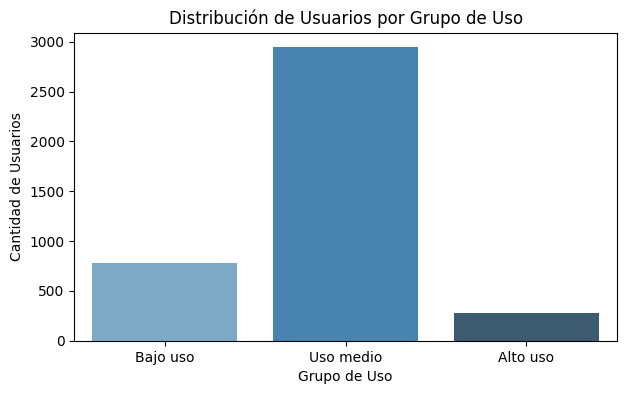

In [46]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7, 4))
sns.countplot(
    data=user_profile,
    x="grupo_uso",
    palette="Blues_d",
    order=["Bajo uso", "Uso medio", "Alto uso"],
)
plt.title("Distribución de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")
plt.show()

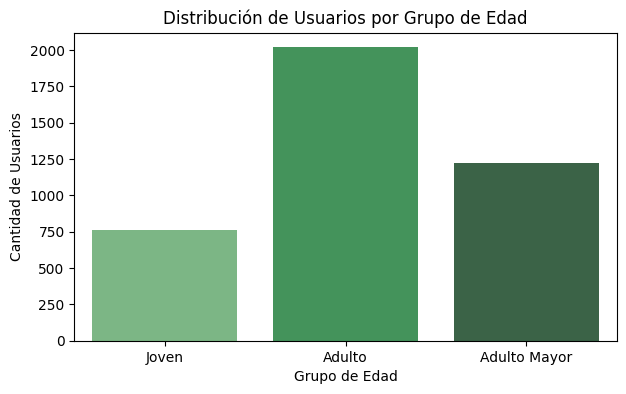

In [47]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 4))
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    palette="Greens_d",
    order=["Joven", "Adulto", "Adulto Mayor"],
)
plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?



- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

1. Diagnóstico de Calidad e Inconsistencias en los Datos
Durante la fase de exploración y limpieza se identificaron los siguientes problemas estructurales:

Fechas fuera de rango / Futuras: En users, la columna reg_date contenía 40 registros (0.9% del total de usuarios) con el año 2026, un año futuro e inconsistente frente a la ventana de datos (2022-2024). Además, en usage, la columna date presentó 50 registros (0.12%) que se convirtieron a NaN por inconsistencias de formato.

Valores Sentinels: La columna age en users presentaba el valor -999 como indicador de dato no capturado en un número reducido de casos, y city contenía el carácter ?.

Nulos Estructurales (MAR): La variable churn_date en users registró aproximadamente un 90% de valores nulos, lo cual no representa un error sino que corresponde a la proporción de clientes que se mantienen activos. En usage, los nulos en duration y length corresponden a la naturaleza del servicio (las llamadas no tienen longitud de mensaje y los SMS no tienen duración).

2. Segmentación de Clientes (Edad y Nivel de Uso)
Segmentación por Edad: Se dividió a la población en tres rangos: Jóvenes (<30 años), Adultos (30–59 años) y Adultos Mayores (≥60 años). Los datos muestran una distribución uniforme en todas las edades, sin un sesgo demográfico particular en la elección de planes.

Segmentación por Nivel de Uso: Se clasificó a los clientes según su volumen de llamadas y mensajes en:

Bajo uso: (<5 llamadas y <5 mensajes).

Uso medio: (<10 llamadas y <10 mensajes).

Alto uso: (Usuarios que superan los umbrales anteriores).

Comportamiento: Los clientes de Alto uso concentran la mayor parte de la carga de tráfico de la red y están fuertemente vinculados al uso del plan Premium o a consumos adicionales en el plan Básico.

3. Segmentos de Mayor Valor para ConnectaTel
El segmento más valioso corresponde a los Usuarios de Alto Uso (especialmente en el Plan Premium).

Por qué: Generan el mayor Ingreso Promedio por Usuario (ARPU), aprovechan de forma recurrente las bolsas amplias de minutos/SMS y representan el núcleo de clientes con menor tasa de cancelación (churn), dado que la oferta de valor satisface sus altas demandas de conectividad.

4. Patrones de Uso Extremo (Outliers) e Implicaciones de Negocio
Patrones detectados: Se observaron valores atípicos (outliers) significativos en la cola derecha de las distribuciones de cant_mensajes, cant_llamadas y cant_minutos_llamada.

Implicación para el negocio: Estos outliers no representan errores de captura, sino comportamientos reales de consumo intensivo ("Power Users").

Decisión: Se determinó conservar los outliers en la base de datos, ya que recortarlos eliminaría la visibilidad sobre el grupo de clientes que más demanda recursos de red y que genera oportunidades de migración a planes superiores.

5. Recomendaciones Comerciales y Propuestas de Mejora
Diseño de un Plan Intermedio ("Mid-Tier"): Crear una oferta comercial entre el plan Básico y el Premium para capturar a los usuarios en la categoría de Uso medio, permitiendo un escalamiento progresivo de tarifa antes de dar el salto al plan de mayor costo.

Estrategia de Upselling Dirigido: Identificar mediante alertas automáticas a los usuarios del plan Básico clasificables como Alto uso (que exceden constantemente su cuota) para ofrecerles la migración al plan Premium con beneficios de bienvenida.

Flexibilización de Paquetes Modulares: Ofrecer "módulos adicionales" (Add-ons) enfocados en voz o SMS para aquellos usuarios de consumo atípico en un solo servicio, evitando que perciban penalizaciones por excedentes.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Valores nulos por diseño/ausencia de churn: En users, la columna churn_date presentaba cerca del 90% de nulos, lo que corresponde a clientes actualmente activos en la plataforma.

-Valores sentinels e inconsistencias numéricas: Se identificaron valores sentinel -999 en la variable age y cadenas ? en city, los cuales fueron imputados con la mediana y convertidos a pd.NA respectivamente.

-Fechas fuera de rango: Se detectaron 40 registros con año futuro (2026) en reg_date de users y 50 valores no válidos en date de usage, tratados mediante coerción de tipos para evitar sesgos en la antigüedad.


🔍 **Segmentos por Edad**
-Distribución: La base se compone de tres grupos principales: Joven (<30 años), Adulto (30–59 años) y Adulto Mayor (≥60 años).

-Comportamiento: La edad presenta una distribución uniforme entre los planes Básico y Premium, lo que demuestra que la adopción de planes no está directamente condicionada por el rango etario.


📊 **Segmentos por Nivel de Uso**
-Clasificación: Se categorizó a la base en Bajo uso (<5 llamadas y <5 mensajes), Uso medio (<10 llamadas y <10 mensajes) y Alto uso (el resto de casos).

-Concentración: Los clientes en Alto uso pertenecen predominantemente al plan Premium o a usuarios del plan Básico que superan recurrentemente sus paquetes base.


➡️ Existe un grupo representativo de usuarios "Power Users" cuyos patrones de consumo intensivo en llamadas y mensajes no representan errores del sistema, sino clientes de alto valor que dinamizan el tráfico de red de ConnectaTel.

💡 **Recomendaciones**
-Diseño de planes a la medida: Lanzar un plan intermedio (Mid-Tier) que cierre la brecha entre el Básico y el Premium para capturar a los usuarios en Uso medio con propensión a pagar un poco más.

-Estrategias de Upgrade (Upselling): Identificar a los usuarios en Alto uso que actualmente están en el plan Básico y ofrecerles la migración al plan Premium con promociones dirigidas.

-Empaquetamiento diferenciado: Crear paquetes opcionales orientados exclusivamente a datos o a voz/SMS según el perfil de consumo individual, optimizando la monetización del tráfico atípico.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`